<h2 style="color:#2563eb;">Hafta 4 - Görev 1</h2>

<p>
Önceki üç harfi bağlam alan veri setini kur
(<strong>X: 3 harf indeksi</strong>, <strong>Y: sıradaki harf</strong>).
</p>

<p>
<strong>Embedding tablosunu (27x2)</strong> oluştur, indeksleme ile embedding'leri çek.
</p>

<p style="color:#6b7280;">
<em>(Part 2, 9:03 - 18:35)</em>
</p>

<hr>



### Bağlam Penceresi (`block_size = 3`) ile $X$ ve $Y$ Oluşturma

In [123]:
import torch
import torch.nn.functional as F

words = open("../hafta3/names.txt", "r").read().splitlines()
chars = sorted(list(set(''.join(words))))
s2i = {s: i + 1 for i, s in enumerate(chars)}
s2i['.'] = 0
i2s = {i: s for s, i in s2i.items()}


block_size = 3


def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = s2i[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

X, Y = build_dataset(words)

print(f'X boyutu: {X.shape}')
print(f'Y boyutu: {Y.shape}')


X boyutu: torch.Size([228146, 3])
Y boyutu: torch.Size([228146])


### Embedding Tablosu ($C$) ve İndeksleme Mantığı

In [124]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)


emb = C[X]
print(f'emb (C[X]) boyutu: {emb.shape}')

emb (C[X]) boyutu: torch.Size([228146, 3, 2])


<h2 style="color:#2563eb;">Görev 2</h2>

<p>
<strong>Gizli katmanı ve çıkış katmanını kur:</strong>
embedding'leri düzleştir, W1 ve b1 ile tanh, W2 ve b2 ile logits.
</p>

<p>
Loss'u geçen haftaki gibi elle hesapla, sonra
<strong style="color:#16a34a;">F.cross_entropy</strong> ile aynı sonucu aldığını göster
ve neden onu tercih ettiğimizi videodan anla.
</p>

### Model Parametrelerini Tanımlama

In [125]:
import torch
import torch.nn.functional as F


g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)


W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)


W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]


for p in parameters:
  p.requires_grad = True

print(f"Toplam parametre sayısı: {sum(p.nelement() for p in parameters)}")

Toplam parametre sayısı: 3481


### İleri Yayılım ve Kayıp Karşılaştırması

In [126]:
emb = C[X]

h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2

counts = logits.exp()

probs = counts / counts.sum(1, keepdims=True)

loss_manual = -probs[torch.arange(X.shape[0]), Y].log().mean()

loss_builtin = F.cross_entropy(logits, Y)

print(f'Elle hesaplanan loss : {loss_manual.item(): .4f}')
print(f'F.cross_entropy ile hesaplanan loss : {loss_builtin.item(): .4f}')




Elle hesaplanan loss :  19.5052
F.cross_entropy ile hesaplanan loss :  19.5052


<h2 style="color:#2563eb;">Görev 3</h2>

<p>
<strong>Eğitim döngüsünü kur: Önce tek bir minibatch'i overfit et, sonra bütün veriyi minibatch'lerle eğit.</strong>

</p>



In [127]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

X_batch = X[:32]
Y_batch = Y[:32]


for k in range(100):
    emb = C[X_batch]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_batch)


    for p in parameters:
        p.grad = None
    loss.backward()


    for p in parameters:
        p.data += -0.1 * p.grad


print(f'Tek batch ezberleme sonrası loss: {loss.item(): .4f}')    

Tek batch ezberleme sonrası loss:  0.3367


### Öğrenme Oranı (Learning Rate)

In [128]:

g = torch.Generator().manual_seed(2147483647) # Modeli tekrar sıfırlıyoruz
C  = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True


lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lri = []
lossi = []

for i in range(1000):
    
    ix = torch.randint(0, X.shape[0], (32,))
    
    
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    
   
    for p in parameters:
        p.grad = None
    loss.backward()
    
   
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
        
    lri.append(lre[i])
    lossi.append(loss.item())

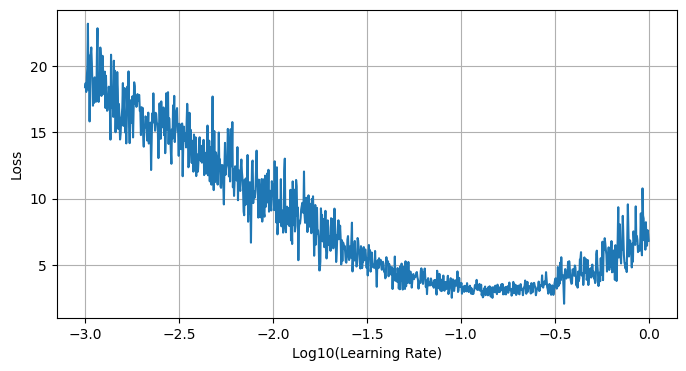

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(lri, lossi)
plt.xlabel("Log10(Learning Rate)")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Train - Dev - Test ayrımı ve Bütün veri ile eğitim

In [130]:

import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])     # %80 Eğitim
Xdev, Ydev = build_dataset(words[n1:n2]) # %10 Doğrulama (Dev)
Xte, Yte = build_dataset(words[n2:])     # %10 Test

print(f"Train örnek: {Xtr.shape[0]}")
print(f"Dev örnek  : {Xdev.shape[0]}")
print(f"Test örnek : {Xte.shape[0]}")

Train örnek: 182625
Dev örnek  : 22655
Test örnek : 22866


### Bütün Modelin Minibatch ile Eğitimi

In [131]:
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True


for i in range(30000):
    
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
   
    for p in parameters:
        p.grad = None
    loss.backward()
    
   
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad


emb_dev = C[Xdev]
h_dev = torch.tanh(emb_dev.view(-1, 6) @ W1 + b1)
logits_dev = h_dev @ W2 + b2
loss_dev = F.cross_entropy(logits_dev, Ydev)

print(f"Dev (Validation) Kümesi Kaybı: {loss_dev.item():.4f}")

Dev (Validation) Kümesi Kaybı: 2.3609


<h2 style="color:#2563eb;">Görev 4</h2>

<p>
<strong>Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl değiştiğini göster.</strong>

</p>



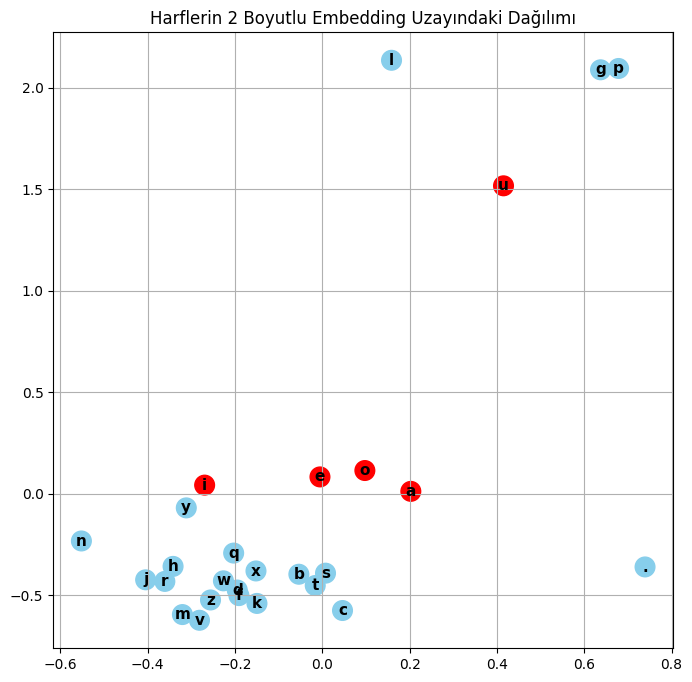

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Sesli harfler
sesli_harfler = ['a', 'e', 'i', 'o', 'u']

# Her harfin rengini belirle
renkler = ['red' if i2s[i] in sesli_harfler else 'skyblue' for i in range(C.shape[0])]

plt.scatter(
    C[:, 0].data,
    C[:, 1].data,
    s=200,
    color=renkler
)

for i in range(C.shape[0]):
    plt.text(
        C[i, 0].item(),
        C[i, 1].item(),
        i2s[i],
        ha='center',
        va='center',
        color='black',
        fontsize=11,
        weight='bold',
    )

plt.title("Harflerin 2 Boyutlu Embedding Uzayındaki Dağılımı")
plt.grid(True)
plt.show()


### Modelden isim örnekleme

In [137]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    out = []
    context = [0] * block_size  
    
    while True:
        
        emb = C[torch.tensor([context])] 
        
        
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1) 
        
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        
        
        context = context[1:] + [ix]
        out.append(i2s[ix])
        if ix == 0:
            break
            
    print(''.join(out[:-1]))

dex
maidalleraria
kayda
molish
tain
lucak
kan
a
samiyauelansr
gotai


### Modeli Büyütme

In [138]:

n_embd = 10     
n_hidden = 200 

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) 
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, 27), generator=g)                 
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(f"Yeni model toplam parametre sayısı: {sum(p.nelement() for p in parameters)}")


lossi = []
stepsi = []

for i in range(200000):
    
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
   
    emb = C[Xtr[ix]] 
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix])
    
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 10000 == 0:
        print(f"Adım {i:6d} | Loss: {loss.item():.4f}")


emb_dev = C[Xdev]
h_dev = torch.tanh(emb_dev.view(-1, block_size * n_embd) @ W1 + b1)
logits_dev = h_dev @ W2 + b2
loss_dev = F.cross_entropy(logits_dev, Ydev)

print(f"\nBüyük Model Dev (Validation) Kaybı: {loss_dev.item():.4f}")

Yeni model toplam parametre sayısı: 11897
Adım      0 | Loss: 29.5834
Adım  10000 | Loss: 3.0803
Adım  20000 | Loss: 2.1712
Adım  30000 | Loss: 2.6516
Adım  40000 | Loss: 2.3879
Adım  50000 | Loss: 2.3811
Adım  60000 | Loss: 2.1002
Adım  70000 | Loss: 1.6226
Adım  80000 | Loss: 1.8787
Adım  90000 | Loss: 1.8762
Adım 100000 | Loss: 2.8580
Adım 110000 | Loss: 2.0402
Adım 120000 | Loss: 1.9790
Adım 130000 | Loss: 2.1161
Adım 140000 | Loss: 2.3174
Adım 150000 | Loss: 1.9566
Adım 160000 | Loss: 1.8101
Adım 170000 | Loss: 2.3380
Adım 180000 | Loss: 2.4741
Adım 190000 | Loss: 2.3197

Büyük Model Dev (Validation) Kaybı: 2.1616


<h2 style="color:#2563eb;">Görev 5</h2>

<p>
<strong>Part 3'e geç. Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster.</strong>

</p>



### Düzeltilmemiş Modelde Tanh Histogramı ve Doygunluk Oranı

Düzeltilmemiş Başlangıç Kaybı: 27.8958


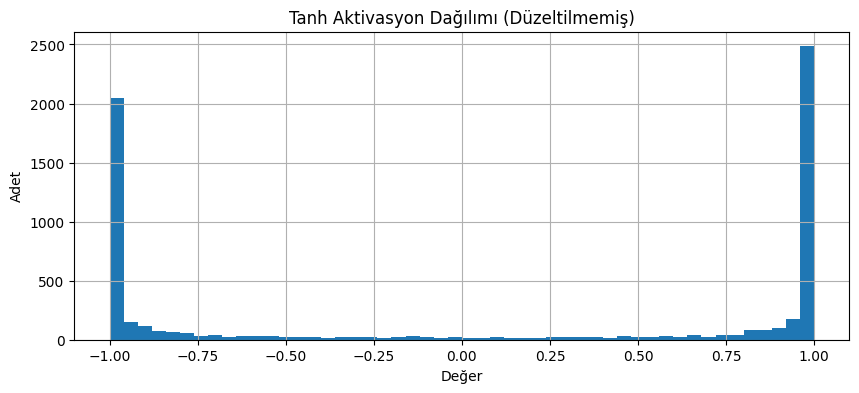

Doymuş (Gradyanı öldüren) Tanh oranı: %60.42


In [139]:
import matplotlib.pyplot as plt

g = torch. Generator().manual_seed(2147483647)
C = torch.randn((27, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True


ix = torch.randint(0, Xtr.shape[0], (32,))
emb = C[Xtr[ix]]
h_preact = emb.view(-1, block_size * n_embd) @ W1 + b1 # Tanh öncesi
h = torch.tanh(h_preact)                               # Tanh sonrası
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr[ix])

print(f"Düzeltilmemiş Başlangıç Kaybı: {loss.item():.4f}")

#Histogram
plt.figure(figsize=(10, 4))
plt.hist(h.view(-1).tolist(), 50)
plt.title("Tanh Aktivasyon Dağılımı (Düzeltilmemiş)")
plt.xlabel("Değer")
plt.ylabel("Adet")
plt.grid(True)
plt.show()


sat_ratio = (h.abs() > 0.99).float().mean().item() * 100
print(f"Doymuş (Gradyanı öldüren) Tanh oranı: %{sat_ratio:.2f}")


### Düzeltme

Kaiming Init Sonrası Başlangıç Kaybı: 3.3177


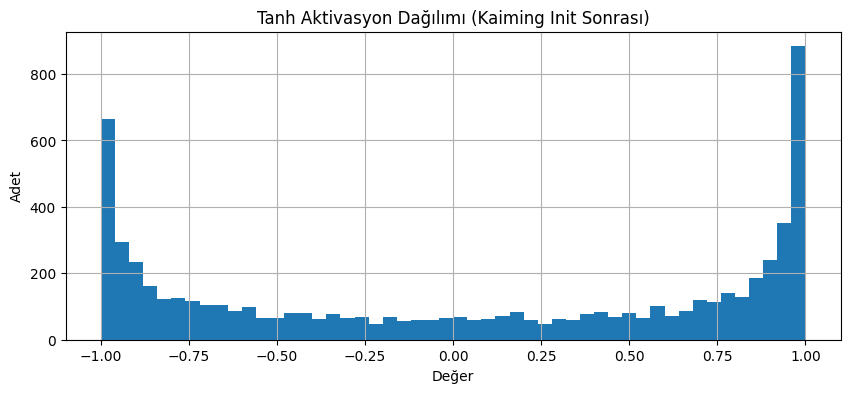

Doymuş (Gradyanı öldüren) Tanh oranı: %11.20


In [140]:
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, n_embd), generator=g)

# Kaiming Init ile W1 ölçeklemesi: (5/3) / sqrt(fan_in)
fan_in = block_size * n_embd 
W1 = torch.randn((fan_in, n_hidden), generator=g) * ((5/3) / (fan_in**0.5))
b1 = torch.randn(n_hidden, generator=g) * 0.01 


W2 = torch.randn((n_hidden, 27), generator=g) * 0.01
b2 = torch.zeros(27)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True


ix = torch.randint(0, Xtr.shape[0], (32,))
emb = C[Xtr[ix]]
h_preact = emb.view(-1, block_size * n_embd) @ W1 + b1
h = torch.tanh(h_preact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr[ix])

print(f"Kaiming Init Sonrası Başlangıç Kaybı: {loss.item():.4f}")


plt.figure(figsize=(10, 4))
plt.hist(h.view(-1).tolist(), 50)
plt.title("Tanh Aktivasyon Dağılımı (Kaiming Init Sonrası)")
plt.xlabel("Değer")
plt.ylabel("Adet")
plt.grid(True)
plt.show()

sat_ratio = (h.abs() > 0.99).float().mean().item() * 100
print(f"Doymuş (Gradyanı öldüren) Tanh oranı: %{sat_ratio:.2f}")

<h2 style="color:#2563eb;">Görev 6</h2>

<p>
<strong>BatchNorm katmanını gizli katmandan sonra ekle. Eğitim sırasında batch istatistiği, tahmin sırasında running mean kullan. BatchNorm'lu ve BatchNorm'suz modelin dev loss'unu karşılaştır.</strong>

</p>



In [141]:
n_embd = 10     
n_hidden = 200  

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, n_embd), generator=g)


fan_in = block_size * n_embd
W1 = torch.randn((fan_in, n_hidden), generator=g) * ((5/3) / (fan_in**0.5))
bngain = torch.ones((1, n_hidden))   
bnbias = torch.zeros((1, n_hidden))  

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running  = torch.ones((1, n_hidden))

W2 = torch.randn((n_hidden, 27), generator=g) * 0.01
b2 = torch.zeros(27)

parameters = [C, W1, bngain, bnbias, W2, b2]
for p in parameters:
    p.requires_grad = True

print(f"Toplam eğitilebilir parametre sayısı: {sum(p.nelement() for p in parameters)}")


for i in range(200000):
    
    
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    emb = C[Xtr[ix]]
    h_preact = emb.view(-1, fan_in) @ W1 
    
    bnmean_i = h_preact.mean(0, keepdim=True)
    bnstd_i  = h_preact.std(0, keepdim=True)
    
    
    h_preact_norm = bngain * (h_preact - bnmean_i) / (bnstd_i + 1e-5) + bnbias
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean_i
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstd_i
    
    
    h = torch.tanh(h_preact_norm)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 20000 == 0:
        print(f"Adım {i:6d} | Loss: {loss.item():.4f}")


with torch.no_grad():
    emb_dev = C[Xdev]
    h_preact_dev = emb_dev.view(-1, fan_in) @ W1
    h_preact_norm_dev = bngain * (h_preact_dev - bnmean_running) / (bnstd_running + 1e-5) + bnbias
    h_dev = torch.tanh(h_preact_norm_dev)
    logits_dev = h_dev @ W2 + b2
    loss_dev = F.cross_entropy(logits_dev, Ydev)

print(f"\nBatchNorm'lu Model Dev (Validation) Kaybı: {loss_dev.item():.4f}")

Toplam eğitilebilir parametre sayısı: 12097
Adım      0 | Loss: 3.3090
Adım  20000 | Loss: 2.0765
Adım  40000 | Loss: 2.0291
Adım  60000 | Loss: 2.2583
Adım  80000 | Loss: 2.3564
Adım 100000 | Loss: 2.2301
Adım 120000 | Loss: 2.1933
Adım 140000 | Loss: 2.1173
Adım 160000 | Loss: 2.0154
Adım 180000 | Loss: 2.2063

BatchNorm'lu Model Dev (Validation) Kaybı: 2.1110


<h2 style="color:#2563eb;">Görev 7</h2>

<p>
<strong>Geçen haftaki Türkçe isim listenle aynı modeli eğit. Türkçe'de ürettiği isimlerden örnekler ve dev loss'u göster. Bigram'ın Türkçe sonuçlarıyla yan yana koy</strong>

</p>



### Türkçe veri setini hazırlama.

In [148]:
import random
import torch
import torch.nn.functional as F


tr_map = str.maketrans(
    {'I': 'ı', 'İ': 'i', 'Ç': 'ç', 'Ğ': 'ğ', 'Ö': 'ö', 'Ş': 'ş', 'Ü': 'ü'}
)


def tr_lower(text):
  return text.translate(tr_map).lower()


# 2. Türkçe isim dosyasını okuma
words_tr = [
    tr_lower(w.strip())
    for w in open("../hafta3/karisik_isimler.csv", "r", encoding='utf-8').read().splitlines()
    if w.strip()
]

# 3. Türkçe sözlük (V = 30)
chars_tr = sorted(list(set(''.join(words_tr))))
s2i_tr = {s: i + 1 for i, s in enumerate(chars_tr)}
s2i_tr['.'] = 0
i2s_tr = {i: s for s, i in s2i_tr.items()}
vocab_size_tr = len(s2i_tr)

print(f'Türkçe isim sayısı: {len(words_tr)}')
print(f'Türkçe sözlük boyutu: {vocab_size_tr} (Beklenen: 30)')

# 4. Türkçe Veri Seti Oluşturma Fonksiyonu
block_size = 3


def build_dataset_tr(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = s2i_tr[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  return torch.tensor(X), torch.tensor(Y)


# 5. Train / Dev / Test Ayrımı (%80, %10, %10)
random.seed(42)
random.shuffle(words_tr)
n1 = int(0.8 * len(words_tr))
n2 = int(0.9 * len(words_tr))

Xtr_tr, Ytr_tr = build_dataset_tr(words_tr[:n1])
Xdev_tr, Ydev_tr = build_dataset_tr(words_tr[n1:n2])
Xte_tr, Yte_tr = build_dataset_tr(words_tr[n2:])

print(
    f'Train örnek: {Xtr_tr.shape[0]} | Dev örnek: {Xdev_tr.shape[0]} | Test'
    f' örnek: {Xte_tr.shape[0]}'
)

Türkçe isim sayısı: 295
Türkçe sözlük boyutu: 30 (Beklenen: 30)
Train örnek: 1437 | Dev örnek: 176 | Test örnek: 184


### Türkçe BatchNorm MLP Modelinin Tanımı ve Eğitimi

In [149]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)


C_tr = torch.randn((vocab_size_tr, n_embd), generator=g)

fan_in = block_size * n_embd  
W1_tr = torch.randn((fan_in, n_hidden), generator=g) * ((5 / 3) / (fan_in**0.5))

bngain_tr = torch.ones((1, n_hidden))
bnbias_tr = torch.zeros((1, n_hidden))
bnmean_running_tr = torch.zeros((1, n_hidden))
bnstd_running_tr = torch.ones((1, n_hidden))

W2_tr = torch.randn((n_hidden, vocab_size_tr), generator=g) * 0.01
b2_tr = torch.zeros(vocab_size_tr)

parameters_tr = [C_tr, W1_tr, bngain_tr, bnbias_tr, W2_tr, b2_tr]
for p in parameters_tr:
  p.requires_grad = True

# Eğitim Döngüsü
max_steps = 100000

for i in range(max_steps):
  ix = torch.randint(0, Xtr_tr.shape[0], (32,))

 
  emb = C_tr[Xtr_tr[ix]]
  h_preact = emb.view(-1, fan_in) @ W1_tr

  bnmean_i = h_preact.mean(0, keepdim=True)
  bnstd_i = h_preact.std(0, keepdim=True)
  h_preact_norm = (
      bngain_tr * (h_preact - bnmean_i) / (bnstd_i + 1e-5) + bnbias_tr
  )

  with torch.no_grad():
    bnmean_running_tr = 0.999 * bnmean_running_tr + 0.001 * bnmean_i
    bnstd_running_tr = 0.999 * bnstd_running_tr + 0.001 * bnstd_i

  h = torch.tanh(h_preact_norm)
  logits = h @ W2_tr + b2_tr
  loss = F.cross_entropy(logits, Ytr_tr[ix])

 
  for p in parameters_tr:
    p.grad = None
  loss.backward()

  
  lr = 0.1 if i < (max_steps * 0.7) else 0.01
  for p in parameters_tr:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'Adım {i:6d} | Loss: {loss.item():.4f}')


  emb_dev = C_tr[Xdev_tr]
  h_preact_dev = emb_dev.view(-1, fan_in) @ W1_tr
  h_preact_norm_dev = (
      bngain_tr * (h_preact_dev - bnmean_running_tr) / (bnstd_running_tr + 1e-5)
      + bnbias_tr
  )
  h_dev = torch.tanh(h_preact_norm_dev)
  logits_dev = h_dev @ W2_tr + b2_tr
  loss_dev_tr = F.cross_entropy(logits_dev, Ydev_tr)

print(
    f"\nTürkçe Model Dev (Validation) Kaybı: {loss_dev_tr.item():.4f}"
)

Adım      0 | Loss: 3.4061
Adım  10000 | Loss: 0.7507
Adım  20000 | Loss: 0.8570
Adım  30000 | Loss: 1.0369
Adım  40000 | Loss: 1.1565
Adım  50000 | Loss: 0.8586
Adım  60000 | Loss: 0.9125
Adım  70000 | Loss: 1.1805
Adım  80000 | Loss: 1.3764
Adım  90000 | Loss: 1.2845

Türkçe Model Dev (Validation) Kaybı: 4.0362


### Türkçe isim üretme.

In [150]:
g = torch.Generator().manual_seed(2147483647)

print("--- Üretilen Türkçe İsimler ---")
for _ in range(15):
  out = []
  context = [0] * block_size

  while True:
    emb = C_tr[torch.tensor([context])]
    h_preact = emb.view(1, -1) @ W1_tr
    h_preact_norm = (
        bngain_tr * (h_preact - bnmean_running_tr) / (bnstd_running_tr + 1e-5)
        + bnbias_tr
    )
    h = torch.tanh(h_preact_norm)
    logits = h @ W2_tr + b2_tr
    probs = F.softmax(logits, dim=1)

    ix = torch.multinomial(
        probs, num_samples=1, replacement=True, generator=g
    ).item()
    context = context[1:] + [ix]
    out.append(i2s_tr[ix])

    if ix == 0:
      break

  print("".join(out[:-1]))

--- Üretilen Türkçe İsimler ---
uzay
ilker
lem
tekir
hayati
kenan
beki
betin
met
ilkay
saadet
erkan
edim
mümine
alperem
